# 🎮 Análise Exploratória — Steam Games Dataset

**6 perguntas | 6+ gráficos | Insights de negócio**
Este dataset reúne informações detalhadas sobre jogos da Steam, incluindo identificação do jogo, data de lançamento, preço, número estimado de jogadores, avaliações positivas e negativas, tempo médio de jogo, quantidade de DLCs, conquistas e recomendações.

Basta executar as células em ordem (`Shift + Enter`).


## 1️⃣ Setup — instalação de dependências

In [ ]:
!pip install -q "kagglehub[pandas-datasets]"

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14

import warnings
warnings.filterwarnings("ignore")

print("✅ Bibliotecas carregadas.")

✅ Bibliotecas carregadas.


## 2️⃣ Carregamento do dataset

> ⚠️ **Se aparecer erro de autenticação Kaggle**: vá em [kaggle.com/settings](https://www.kaggle.com/settings) → *Create New Token* (baixa `kaggle.json`). No Colab, descomente o bloco abaixo, faça upload do arquivo e rode.

In [ ]:
# === Descomente se precisar autenticar ===
# from google.colab import files
# files.upload()  # selecione kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

In [ ]:
file_path = "games.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "fronkongames/steam-games-dataset",
    file_path,
)

print(f"Dataset carregado: {df.shape[0]:,} jogos x {df.shape[1]} colunas\n")
df.head()

Using Colab cache for faster access to the 'steam-games-dataset' dataset.
Dataset carregado: 122,611 jogos x 39 colunas



,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


## 3️⃣ Limpeza e feature engineering

In [ ]:
df["Release date"] = pd.to_datetime(df["Release date"], errors="coerce")
df["Year"] = df["Release date"].dt.year

def midpoint(rng):
    try:
        a, b = rng.replace(",", "").split(" - ")
        return (int(a) + int(b)) / 2
    except Exception:
        return np.nan

df["Owners_est"] = df["Estimated owners"].apply(midpoint)
df["Total_reviews"] = df["Positive"] + df["Negative"]
df["Approval_rate"] = np.where(
    df["Total_reviews"] > 0,
    df["Positive"] / df["Total_reviews"] * 100,
    np.nan,
)
df["Is_free"] = df["Price"] == 0

bins = [0, 5, 10, 20, 40, 60, np.inf]
labels = ["≤$5", "$5-10", "$10-20", "$20-40", "$40-60", ">$60"]
df["Price_band"] = pd.cut(df["Price"], bins=bins, labels=labels, include_lowest=False)

print("✅ Features criadas.")
df[["Name", "Year", "Price", "Owners_est", "Approval_rate", "Price_band"]].head()

✅ Features criadas.


,Name,Year,Price,Owners_est,Approval_rate,Price_band
2539430,"Aug 1, 2023",NaN,0,NaN,NaN,NaN
496350,"Jul 29, 2016",NaN,65,NaN,98.823529,>$60
1034400,"May 6, 2019",NaN,0,NaN,87.500000,NaN
3292190,"Oct 31, 2024",NaN,0,NaN,NaN,NaN
3631080,"Apr 24, 2025",NaN,0,NaN,NaN,NaN


---
# ❓ PERGUNTA 1 — Qual o preço mediano por gênero na Steam?
# Análise: quanto cobra cada gênero (considerando apenas jogos pagos)

Total de jogos pagos analisados: 111,470
Faixa de preço: $10.00 – $100.00
Gêneros no gráfico: 12



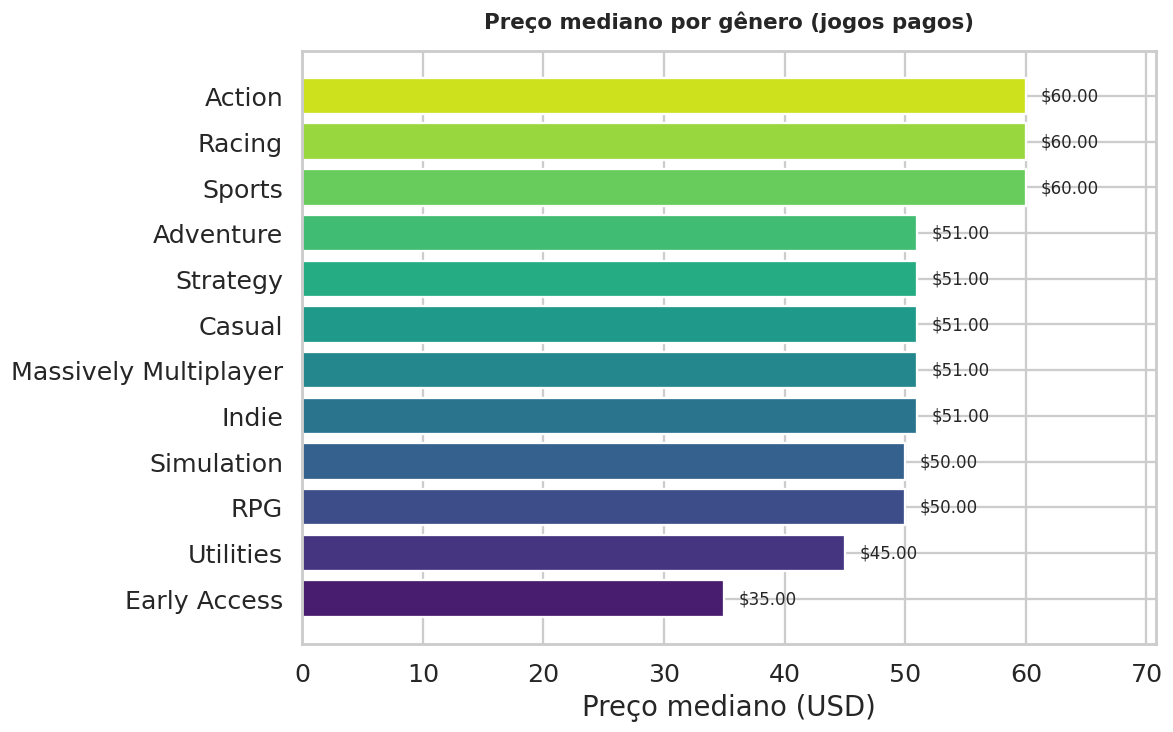

💎 Gênero mais caro: Action ($60.00)
💸 Gênero mais barato (top 12): Early Access ($35.00)
📊 Diferença: $25.00


In [ ]:
# ❓ PERGUNTA 1 — Qual o preço mediano por gênero na Steam?
# Análise: quanto cobra cada gênero (considerando apenas jogos pagos)

# 🔧 Garantir que Price é numérico
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Explode gêneros (cada jogo pode ter múltiplos)
genres_exp = (
    df[["Genres", "Price"]]
    .dropna(subset=["Genres", "Price"])
    .copy()
)
genres_exp["Genres"] = genres_exp["Genres"].str.split(",")
genres_exp = genres_exp.explode("Genres")
genres_exp["Genres"] = genres_exp["Genres"].str.strip()
genres_exp = genres_exp[genres_exp["Genres"] != ""]

# Preço mediano considerando APENAS jogos pagos (senão F2P puxa tudo pra zero)
paid_genres = genres_exp[genres_exp["Price"] > 0]

# Filtra gêneros com volume mínimo para estatística confiável
volume_paid = paid_genres["Genres"].value_counts()
relevant_genres = volume_paid[volume_paid >= 200].index

genre_median_price = (
    paid_genres[paid_genres["Genres"].isin(relevant_genres)]
    .groupby("Genres")["Price"]
    .median()
    .sort_values(ascending=False)
    .head(12)
)

# --- Diagnóstico rápido ---
print(f"Total de jogos pagos analisados: {len(paid_genres):,}")
print(f"Faixa de preço: ${paid_genres['Price'].min():.2f} – ${paid_genres['Price'].max():.2f}")
print(f"Gêneros no gráfico: {len(genre_median_price)}\n")

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(11, 7))

colors = sns.color_palette("viridis", len(genre_median_price))
bars = ax.barh(
    genre_median_price.index[::-1],
    genre_median_price.values[::-1],
    color=colors,
)
ax.set_title("Preço mediano por gênero (jogos pagos)", fontsize=14, pad=15)
ax.set_xlabel("Preço mediano (USD)")
ax.set_xlim(0, genre_median_price.max() * 1.18)

for bar, val in zip(bars, genre_median_price.values[::-1]):
    ax.text(
        val + genre_median_price.max() * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"${val:.2f}",
        va="center",
        fontsize=11,
    )

plt.tight_layout()
plt.show()

# --- Insight numérico ---
top_preco = genre_median_price.index[0]
bottom_preco = genre_median_price.index[-1]
print(f"💎 Gênero mais caro: {top_preco} (${genre_median_price.iloc[0]:.2f})")
print(f"💸 Gênero mais barato (top 12): {bottom_preco} (${genre_median_price.iloc[-1]:.2f})")
print(f"📊 Diferença: ${genre_median_price.iloc[0] - genre_median_price.iloc[-1]:.2f}")

### 💡 Insight 1
Jogos de ação, corrida e esportes são os mais caros na atualidade. Já jogos de acesso antecipado e aplicativos utilitários são os mais baratos, apresentando uma diferença de $25 do mais barato ao mais caro

---
## ❓ Pergunta 2 — Qual a média de preço e quantos jogam jogos pagos e de graça?

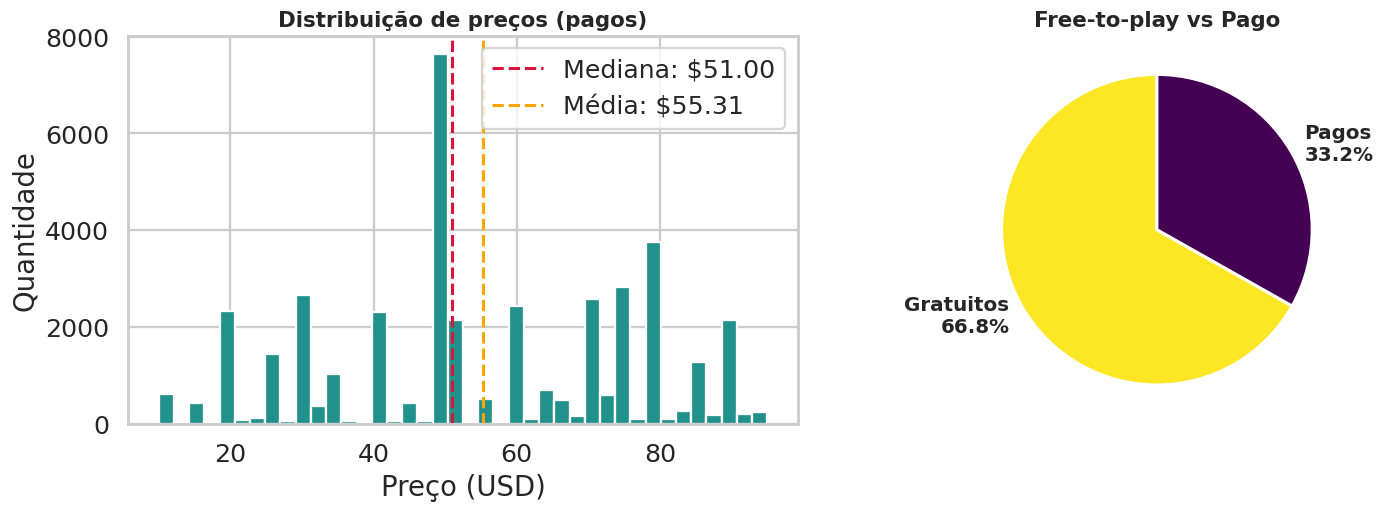

Mediana: $51.00 | Média: $55.31 | F2P: 66.8%


In [ ]:
paid = df[(df["Price"] > 0) & (df["Price"] < 100)]
free_share = df["Is_free"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(paid["Price"], bins=40, color="#21918c", edgecolor="white")
axes[0].axvline(paid["Price"].median(), color="crimson", linestyle="--", linewidth=2,
                label=f"Mediana: ${paid['Price'].median():.2f}")
axes[0].axvline(paid["Price"].mean(), color="orange", linestyle="--", linewidth=2,
                label=f"Média: ${paid['Price'].mean():.2f}")
axes[0].set_title("Distribuição de preços (pagos)")
axes[0].set_xlabel("Preço (USD)")
axes[0].set_ylabel("Quantidade")
axes[0].legend()

axes[1].pie(
    [free_share, 100 - free_share],
    labels=[f"Gratuitos\n{free_share:.1f}%", f"Pagos\n{100-free_share:.1f}%"],
    colors=["#fde725", "#440154"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 13, "fontweight": "bold"},
)
axes[1].set_title("Free-to-play vs Pago")

plt.tight_layout()
plt.show()

print(f"Mediana: ${paid['Price'].median():.2f} | Média: ${paid['Price'].mean():.2f} | F2P: {free_share:.1f}%")

### 💡 Insight 2
A base analisada é majoritariamente **free-to-play (66,8%)**, enquanto os jogos pagos representam cerca de **um terço do total (33,2%)**. Entre os pagos, os preços se concentram próximos de **US$ 50–55**, indicando um padrão de precificação relativamente elevado.


---
## ❓ Pergunta 3 — Gêneros dominantes

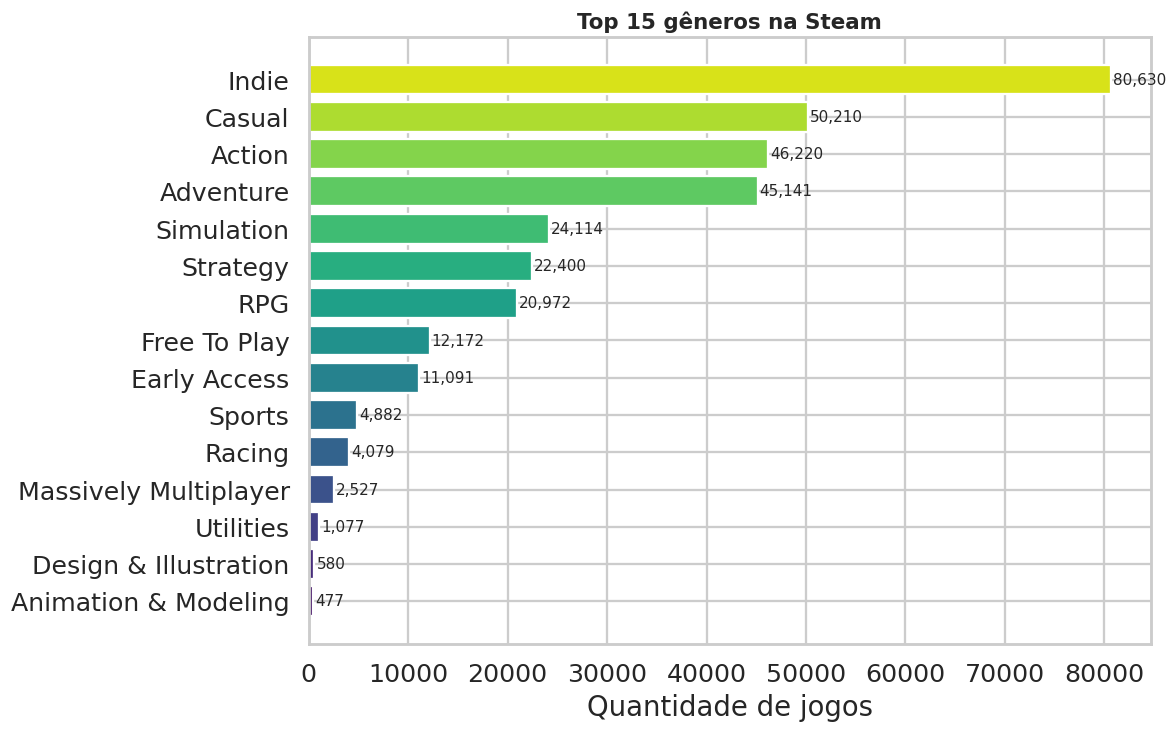

Líder: Indie (80,630 jogos)


In [ ]:
genres_series = df["Genres"].dropna().str.split(",").explode().str.strip()
top_genres = genres_series.value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    top_genres.index[::-1],
    top_genres.values[::-1],
    color=sns.color_palette("viridis", len(top_genres)),
)
ax.set_title("Top 15 gêneros na Steam")
ax.set_xlabel("Quantidade de jogos")
for bar, val in zip(bars, top_genres.values[::-1]):
    ax.text(val + 200, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=10)
plt.tight_layout()
plt.show()

print(f"Líder: {top_genres.index[0]} ({top_genres.iloc[0]:,} jogos)")

### 💡 Insight 3
O proximo gráfico é sobre os generos dominantes, generos que mais existem na loja da steam e como podemos observar jogos Indie simplesmente prevalece no top 1 com bastante folga, seguido no top 3 casual, ação e aventuras que estão bem páreos. E os ultimos colocados temos jogos de Animação, Design e Utilitários.


---
## ❓ Pergunta 4 — Preço vs avaliação

  Price_band       mean     median  count
0      $5-10  86.122146  90.000000    105
1     $10-20  85.035809  88.265481    731
2     $20-40  85.297407  88.540664   2894
3     $40-60  80.601419  84.615385   5037
4       >$60  79.633727  82.550930   3795


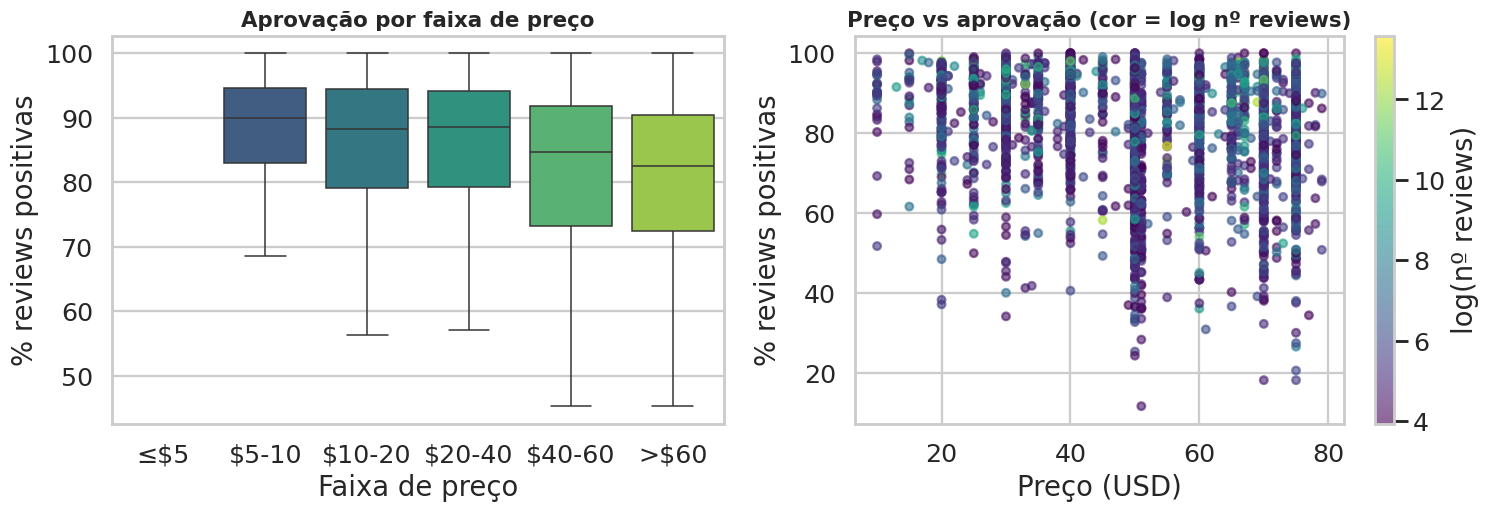

Correlação preço × aprovação: -0.152


In [ ]:
reliable = df[(df["Total_reviews"] >= 50) & (df["Price"] > 0) & (df["Price"] < 80)]

approval_by_band = (
    reliable.groupby("Price_band", observed=True)["Approval_rate"]
    .agg(["mean", "median", "count"])
    .reset_index()
)
print(approval_by_band)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=reliable, x="Price_band", y="Approval_rate",
            ax=axes[0], palette="viridis", showfliers=False)
axes[0].set_title("Aprovação por faixa de preço")
axes[0].set_xlabel("Faixa de preço")
axes[0].set_ylabel("% reviews positivas")

sample = reliable.sample(min(3000, len(reliable)), random_state=42)
sc = axes[1].scatter(
    sample["Price"], sample["Approval_rate"],
    c=np.log1p(sample["Total_reviews"]),
    cmap="viridis", alpha=0.6, s=25,
)
axes[1].set_title("Preço vs aprovação (cor = log nº reviews)")
axes[1].set_xlabel("Preço (USD)")
axes[1].set_ylabel("% reviews positivas")
plt.colorbar(sc, ax=axes[1], label="log(nº reviews)")

plt.tight_layout()
plt.show()

corr = reliable[["Price", "Approval_rate"]].corr().iloc[0, 1]
print(f"Correlação preço × aprovação: {corr:.3f}")

### 💡 Insight 4
A aprovação tende a ser mais alta nas faixas de preço mais baixas e vai caindo levemente conforme o preço aumenta, especialmente acima de **US$ 40**. O scatter reforça que jogos caros ainda podem performar bem, mas apresentam maior dispersão e mais casos com aprovação baixa.


---
## ❓ PERGUNTA 5 — O Efeito Live-Service: Volume de DLCs vs. Satisfação do Público

**Análise:** Jogos com um alto volume de DLCs lançados conseguem manter notas mais altas ao longo do tempo (comunidade engajada e fiel) ou sofrem rejeição do público (review bombing por percepção de monetização agressiva)?

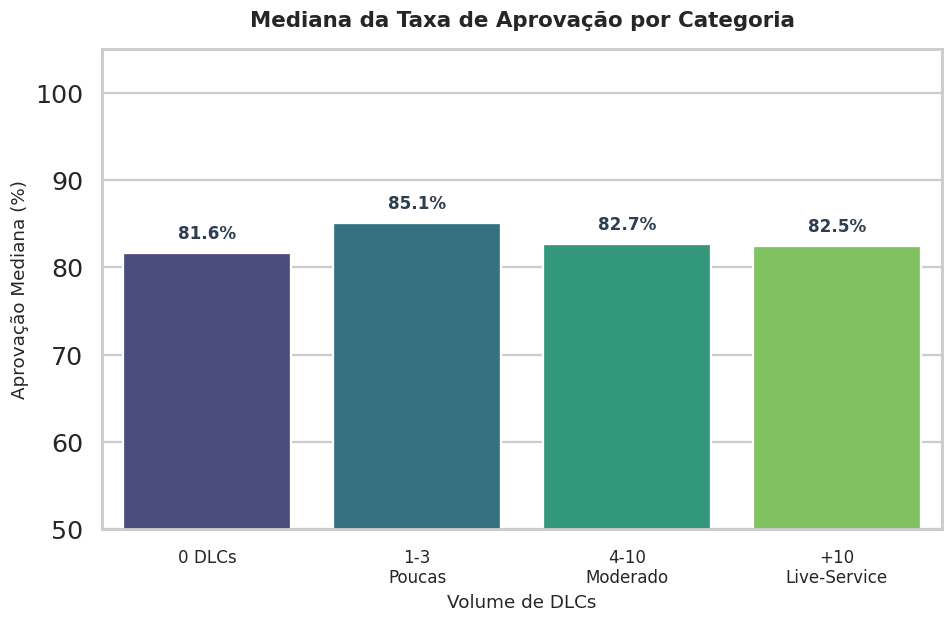

In [30]:
# Criar labels mais organizados (quebra de linha ajuda MUITO)
labels_tiers = [
    "0 DLCs",
    "1-3\nPoucas",
    "4-10\nModerado",
    "+10\nLive-Service"
]

ordem_tiers = ["0 DLCs", "1-3 (Poucas)", "4-10 (Moderado)", "+10 (Live-Service)"]

# Calcular mediana
df_mediana = (
    df_dlc
    .groupby("DLC_Tier")["Approval_rate"]
    .median()
    .reindex(ordem_tiers)
    .reset_index()
)

# Criar figura única
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=df_mediana,
    x="DLC_Tier",
    y="Approval_rate",
    order=ordem_tiers,
    palette="viridis"
)

# Títulos e labels
ax.set_title(
    "Mediana da Taxa de Aprovação por Categoria",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Volume de DLCs", fontsize=12)
ax.set_ylabel("Aprovação Mediana (%)", fontsize=12)

# Ajustar labels do eixo X
ax.set_xticklabels(labels_tiers, fontsize=11)

# Espaço para valores acima das barras
ax.set_ylim(50, 105)

# Adicionar valores
for p in ax.patches:
    altura = p.get_height()

    if not np.isnan(altura):
        ax.annotate(
            f"{altura:.1f}%",
            (p.get_x() + p.get_width() / 2, altura + 1.2),
            ha='center',
            va='bottom',
            fontweight='bold',
            fontsize=11,
            color='#2c3e50'
        )

plt.tight_layout()
plt.show()

### 💡 Insight 5
Há um leve ganho de aprovação em jogos com poucos DLCs (1–3), sugerindo que conteúdo extra moderado é bem recebido pelos jogadores. Porém, volumes maiores de DLC não aumentam a aprovação, indicando retorno limitado após esse ponto.



---
## ❓ Pergunta 6 — Perfil dos jogos com alta aprovação

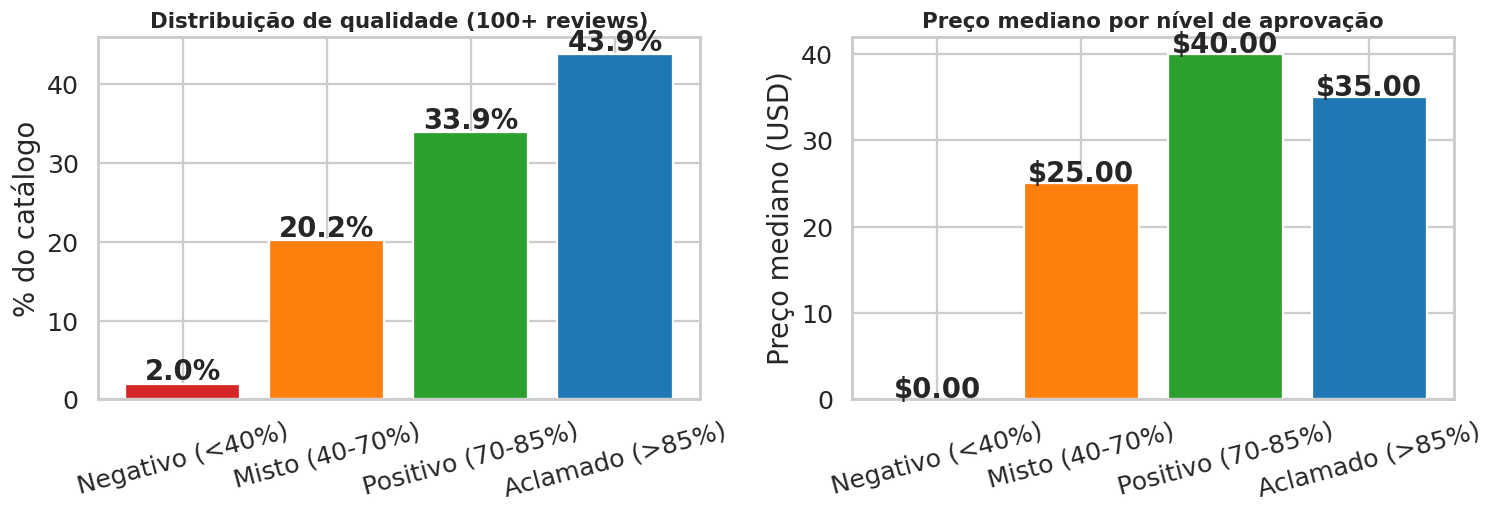

Aclamados: 43.9% do catálogo popular.


In [ ]:
popular = df[df["Total_reviews"] >= 100].copy()
popular["Quality_tier"] = pd.cut(
    popular["Approval_rate"],
    bins=[0, 40, 70, 85, 100],
    labels=["Negativo (<40%)", "Misto (40-70%)", "Positivo (70-85%)", "Aclamado (>85%)"],
)

tier_share = popular["Quality_tier"].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tier_colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]

axes[0].bar(tier_share.index.astype(str), tier_share.values, color=tier_colors)
axes[0].set_title("Distribuição de qualidade (100+ reviews)")
axes[0].set_ylabel("% do catálogo")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(tier_share.values):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

price_by_tier = popular.groupby("Quality_tier", observed=True)["Price"].median()
axes[1].bar(price_by_tier.index.astype(str), price_by_tier.values, color=tier_colors)
axes[1].set_title("Preço mediano por nível de aprovação")
axes[1].set_ylabel("Preço mediano (USD)")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(price_by_tier.values):
    axes[1].text(i, v + 0.2, f"${v:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Aclamados: {tier_share.iloc[-1]:.1f}% do catálogo popular.")

### 💡 Insight 6
A maior parte dos jogos com 100+ reviews está em níveis altos de qualidade: **43,9% aclamados** e **33,9% positivos**. O preço mediano também é maior entre os jogos positivos/aclamados, sugerindo que jogos mais bem avaliados conseguem sustentar preços mais altos.
